# 01 — Exploratory Data Analysis

**Dataset:** SAP Cloud Infrastructure Dataset (Zenodo, CC BY 4.0)  
**Scope:** 123,357 VMs monitored over 30 days (August 2024)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("../data/processed")

## 1. Load data

In [2]:
df = pd.read_csv(DATA / "vm_utilization_summary.csv")
print(f"VMs: {len(df):,}")
df.head()

VMs: 123,363


,instance,cpu_mean,cpu_median,cpu_p5,cpu_p95,cpu_min,cpu_max,cpu_n,mem_mean,mem_median,mem_p5,mem_p95,mem_min,mem_max,mem_n
0,instance-00004b7a-bebb-4f1c-86e1-f62ccfe134d6,4.3586,4.3586,4.3586,4.3586,4.3586,4.3586,2,23.4275,23.4275,23.4275,23.4275,23.4275,23.4275,2
1,instance-00011354-845c-4726-b714-2057d6d1bf6b,3.4742,3.4212,3.0721,4.5587,2.4725,4.8724,62,99.7741,99.7803,99.7525,99.7803,99.7525,99.7803,62
2,instance-0001a3ca-b5f1-472c-96e5-1f3f28d84e48,3.2407,3.8107,0.5839,4.2009,0.5839,4.2009,37,99.8175,99.8190,99.8052,99.8193,99.8052,99.8198,37
3,instance-0001fbbb-7c5d-4366-a6cf-d0acd2ddbca6,0.7394,0.7394,0.7394,0.7394,0.7394,0.7394,2,3.7935,3.7935,3.7935,3.7935,3.7935,3.7935,2
4,instance-0002f0a6-2a95-4a70-91de-91074b585287,14.3698,17.8023,1.8301,18.9266,1.8301,18.9266,21,89.4270,96.3143,68.5652,96.7116,68.5652,96.7787,21


## 2. CPU utilization distribution

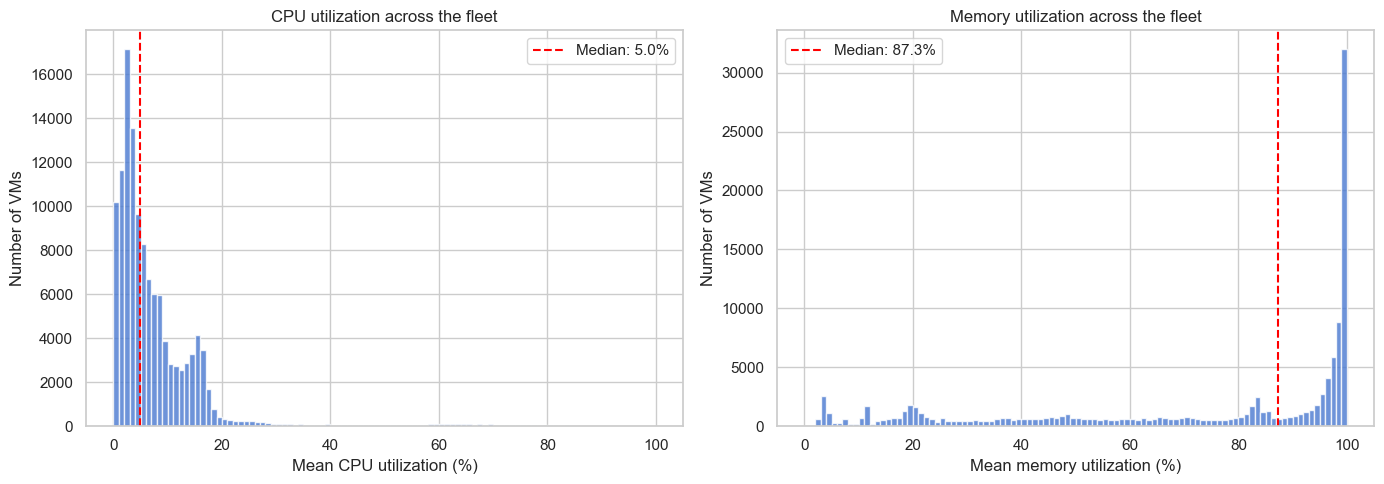

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["cpu_mean"], bins=100, edgecolor="white", alpha=0.8)
axes[0].axvline(df["cpu_mean"].median(), color="red", linestyle="--", label=f'Median: {df["cpu_mean"].median():.1f}%')
axes[0].set_xlabel("Mean CPU utilization (%)")
axes[0].set_ylabel("Number of VMs")
axes[0].set_title("CPU utilization across the fleet")
axes[0].legend()

axes[1].hist(df["mem_mean"], bins=100, edgecolor="white", alpha=0.8)
axes[1].axvline(df["mem_mean"].median(), color="red", linestyle="--", label=f'Median: {df["mem_mean"].median():.1f}%')
axes[1].set_xlabel("Mean memory utilization (%)")
axes[1].set_ylabel("Number of VMs")
axes[1].set_title("Memory utilization across the fleet")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/utilization_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. CPU vs Memory scatter

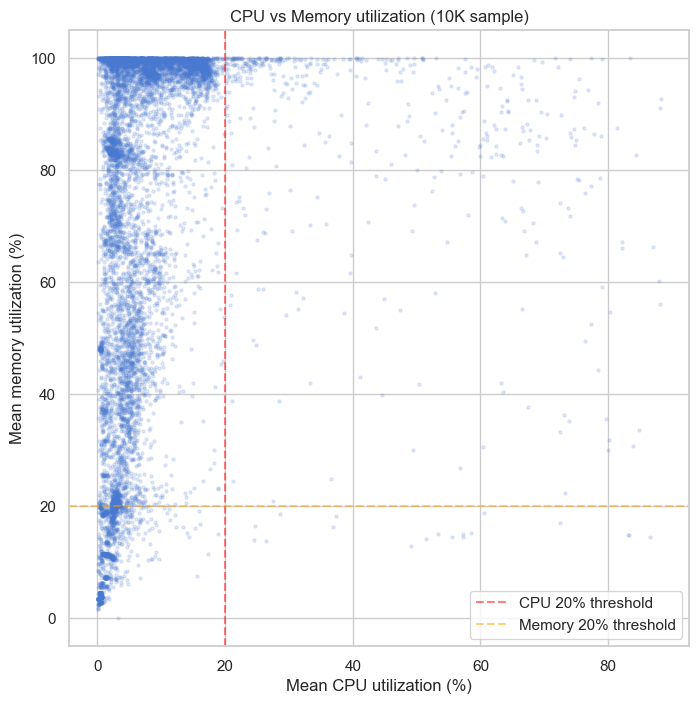

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
sample = df.sample(min(10000, len(df)), random_state=42)
ax.scatter(sample["cpu_mean"], sample["mem_mean"], alpha=0.15, s=5)
ax.set_xlabel("Mean CPU utilization (%)")
ax.set_ylabel("Mean memory utilization (%)")
ax.set_title("CPU vs Memory utilization (10K sample)")
ax.axvline(20, color="red", linestyle="--", alpha=0.5, label="CPU 20% threshold")
ax.axhline(20, color="orange", linestyle="--", alpha=0.5, label="Memory 20% threshold")
ax.legend()
plt.savefig("../reports/figures/cpu_vs_memory.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. VM classification

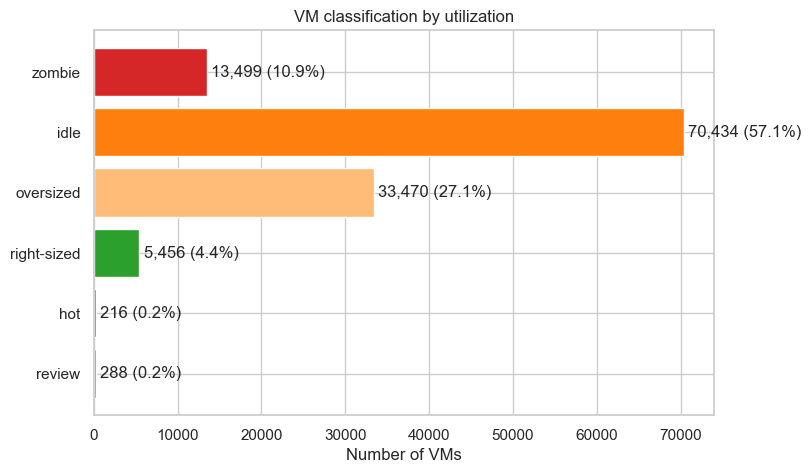

In [5]:
classified = pd.read_csv(DATA / "vm_classified.csv")
counts = classified["class"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"zombie": "#d62728", "idle": "#ff7f0e", "oversized": "#ffbb78",
          "right-sized": "#2ca02c", "hot": "#1f77b4", "review": "#9467bd"}
order = ["zombie", "idle", "oversized", "right-sized", "hot", "review"]
bars = [counts.get(c, 0) for c in order]
bar_colors = [colors[c] for c in order]

ax.barh(order, bars, color=bar_colors, edgecolor="white")
for i, v in enumerate(bars):
    ax.text(v + 500, i, f"{v:,} ({v/len(classified)*100:.1f}%)", va="center")
ax.set_xlabel("Number of VMs")
ax.set_title("VM classification by utilization")
ax.invert_yaxis()
plt.savefig("../reports/figures/vm_classification.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Key statistics

| Metric | Value |
|--------|-------|
| Total VMs | 123,363 |
| Median CPU | 5.0% |
| Waste candidates | 95.2% |
| Zombies (CPU<5%, Mem<20%) | 10.9% |

In [6]:
print("Fleet summary:")
print(f"  Total VMs:          {len(df):,}")
print(f"  Median CPU:         {df['cpu_mean'].median():.1f}%")
print(f"  Median Memory:      {df['mem_mean'].median():.1f}%")
print(f"  CPU P95:            {df['cpu_mean'].quantile(0.95):.1f}%")
waste = classified[classified["class"].isin(["zombie", "idle", "oversized"])]
print(f"  Waste candidates:   {len(waste):,} ({len(waste)/len(classified)*100:.1f}%)")

Fleet summary:
  Total VMs:          123,363
  Median CPU:         5.0%
  Median Memory:      87.3%
  CPU P95:            18.8%
  Waste candidates:   117,403 (95.2%)
